# Predictive Modelling
Build a churn prediction model that **maximizes identification of churn-risk customers**, supports **risk segmentation**, and enables **targeted retention actions**, rather than blindly maximizing accuracy.

### Churn Definition

* **Churn = customer leaves the company**

* Business cost of:

  * False Negative (FN) → Customer will actually churn but model predict no churn (HIGH COST)

  * False Positive (FP) → Customer will not churn but model predict churn - To keep those customers company offers unnecessary discount (LOWER COST)


**Therefore:**
Recall for churners matters more than accuracy.

In [1]:
## Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

from sklearn.model_selection import GridSearchCV

from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import RandomOverSampler, SMOTE

In [2]:
## Load cleaned and transformed dataset (after feature engineering)
df = pd.read_csv("..\\data\\processed\\cleaned_feature_engineering_telco_customer_churn.csv")

print(df.shape)
df.head()

(7021, 24)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,MonthlyCharges,TotalCharges,Churn,InternetService_Fiber optic,InternetService_No,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0.0,-0.440278,1,0,-1.279910,0,0,0,1,0,...,-1.161010,-0.993745,0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,1.0,-0.440278,0,0,0.064885,1,0,1,0,1,...,-0.260031,-0.172844,0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
2,1.0,-0.440278,0,0,-1.239159,1,0,1,1,0,...,-0.363095,-0.959182,1,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,1.0,-0.440278,0,0,0.513151,0,0,1,0,1,...,-0.747091,-0.194364,0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
4,0.0,-0.440278,0,0,-1.239159,1,0,0,0,0,...,0.197108,-0.939980,1,1.0,0.0,0.0,0.0,0.0,1.0,0.0


### Split the data

In [3]:
## Features and target
X = df.drop('Churn', axis=1)
y = df['Churn']

print(X.shape, y.shape)

(7021, 23) (7021,)


In [4]:
## Split the data into training and testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state = 42)

print("X_train Shape: ", X_train.shape)
print("X_test Shape: ", X_test.shape)
print("y_train Shape: ", y_train.shape)
print("y_test Shape: ", y_test.shape)

X_train Shape:  (5616, 23)
X_test Shape:  (1405, 23)
y_train Shape:  (5616,)
y_test Shape:  (1405,)


## Build Model

In [5]:
## Logistic Regression Model
log_reg_model = LogisticRegression(class_weight='balanced')

# Train the model
log_reg_model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

### Evaluate

In [6]:
## Prediction on training data
y_train_pred = log_reg_model.predict(X_train)

## Calculate accuracy
training_score = classification_report(y_train, y_train_pred)

In [7]:
## Prediction on testing data
y_test_pred = log_reg_model.predict(X_test)

## Calculate accuracy
test_score = classification_report(y_test, y_test_pred)

print("\n\nTraining Score\n", training_score, "\n\n\nTesting Score\n", test_score)



Training Score
               precision    recall  f1-score   support

           0       0.91      0.73      0.81      4122
           1       0.52      0.80      0.63      1494

    accuracy                           0.75      5616
   macro avg       0.72      0.77      0.72      5616
weighted avg       0.81      0.75      0.76      5616
 


Testing Score
               precision    recall  f1-score   support

           0       0.92      0.74      0.82      1033
           1       0.53      0.81      0.64       372

    accuracy                           0.76      1405
   macro avg       0.72      0.77      0.73      1405
weighted avg       0.81      0.76      0.77      1405



#### Comment:
It shows training and testing accuracy is 75% and 76%  and recall is 77% which is not bad but let's try to improve accuracy with another non-linear model.

## Build model with Random Forest

In [8]:
## Train the model
rf_model = RandomForestClassifier(random_state=42, class_weight='balanced')
rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [9]:
## Predict with model
y_train_pred = rf_model.predict(X_train)
y_test_pred = rf_model.predict(X_test)

In [10]:
## Evaluate
training_score = classification_report(y_train, y_train_pred)
test_score = classification_report(y_test, y_test_pred)

print("\n\nTraining Score\n", training_score, "\n\n\nTesting Score\n", test_score)



Training Score
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      4122
           1       0.99      1.00      1.00      1494

    accuracy                           1.00      5616
   macro avg       1.00      1.00      1.00      5616
weighted avg       1.00      1.00      1.00      5616
 


Testing Score
               precision    recall  f1-score   support

           0       0.82      0.92      0.87      1033
           1       0.66      0.44      0.53       372

    accuracy                           0.79      1405
   macro avg       0.74      0.68      0.70      1405
weighted avg       0.78      0.79      0.78      1405



#### Comment: 
It shows overfitting (training accuracy is high and test accuracy is low)

### Hyperparameter Tuning

In [11]:
## Train the model
rf_model = RandomForestClassifier(
    n_estimators = 200,
    max_depth = 10,
    class_weight='balanced',
    random_state=42)
rf_model.fit(X_train, y_train)

## Predict with model
y_train_pred = rf_model.predict(X_train)
y_test_pred = rf_model.predict(X_test)


## Evaluate
training_score = classification_report(y_train, y_train_pred)
test_score = classification_report(y_test, y_test_pred)

print("\n\nTraining Score\n", training_score, "\n\n\nTesting Score\n", test_score)



Training Score
               precision    recall  f1-score   support

           0       0.96      0.85      0.90      4122
           1       0.69      0.90      0.78      1494

    accuracy                           0.87      5616
   macro avg       0.83      0.88      0.84      5616
weighted avg       0.89      0.87      0.87      5616
 


Testing Score
               precision    recall  f1-score   support

           0       0.88      0.81      0.84      1033
           1       0.57      0.70      0.62       372

    accuracy                           0.78      1405
   macro avg       0.72      0.75      0.73      1405
weighted avg       0.80      0.78      0.78      1405



In [13]:
## Train the model
rf_model = RandomForestClassifier(
    n_estimators = 200,
    max_depth = 15,
    class_weight='balanced',
    random_state=42)
rf_model.fit(X_train, y_train)

## Predict with model
y_train_pred = rf_model.predict(X_train)
y_test_pred = rf_model.predict(X_test)

## Evaluate
training_score = classification_report(y_train, y_train_pred)
test_score = classification_report(y_test, y_test_pred)

print("\n\nTraining Score\n", training_score, "\n\n\nTesting Score\n", test_score)



Training Score
               precision    recall  f1-score   support

           0       1.00      0.97      0.98      4122
           1       0.92      1.00      0.96      1494

    accuracy                           0.98      5616
   macro avg       0.96      0.98      0.97      5616
weighted avg       0.98      0.98      0.98      5616
 


Testing Score
               precision    recall  f1-score   support

           0       0.84      0.88      0.86      1033
           1       0.63      0.55      0.59       372

    accuracy                           0.80      1405
   macro avg       0.74      0.72      0.72      1405
weighted avg       0.79      0.80      0.79      1405



### Grid Search CV

In [14]:
param_grid = {
    'n_estimators': [200,300, 400],
    'max_depth': [10,15],
    'min_samples_leaf': [12,15,18],
    'max_features': ['log2'],
    'class_weight':['balanced'],
}

clf_grid = GridSearchCV(
    estimator = RandomForestClassifier(random_state=42),
    param_grid = param_grid,
    cv=5,
    n_jobs=-1
)

## Fit
clf_grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'class_weight': ['balanced'], 'max_depth': [10, 15], 'max_features': ['log2'], 'min_samples_leaf': [12, 15, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter can

In [15]:
## Get the best model
best_clf = clf_grid.best_estimator_

## Predict with model
y_train_pred = best_clf.predict(X_train)
y_test_pred = best_clf.predict(X_test)

## Evaluate
training_score = classification_report(y_train, y_train_pred)
test_score = classification_report(y_test, y_test_pred)

print("\n\nTraining Score\n", training_score, "\n\n\nTesting Score\n", test_score)



Training Score
               precision    recall  f1-score   support

           0       0.93      0.79      0.85      4122
           1       0.59      0.83      0.69      1494

    accuracy                           0.80      5616
   macro avg       0.76      0.81      0.77      5616
weighted avg       0.84      0.80      0.81      5616
 


Testing Score
               precision    recall  f1-score   support

           0       0.90      0.78      0.83      1033
           1       0.55      0.75      0.64       372

    accuracy                           0.77      1405
   macro avg       0.72      0.77      0.74      1405
weighted avg       0.81      0.77      0.78      1405



#### Comment:
Testing accuracy is not increasing inspite of hyperparameter tuning. Let's try some feature engineering.

In [16]:
## Find out best features
rf = RandomForestClassifier(random_state=42, n_estimators=100)
rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [17]:
feature_importance = (
    pd.DataFrame({
        'Feature': X.columns,
        'Importance': rf.feature_importances_
    })
    .sort_values(by='Importance', ascending=False)
)

feature_importance.head(20)

,Feature,Importance
15,TotalCharges,0.193965
14,MonthlyCharges,0.180483
4,tenure,0.174190
16,InternetService_Fiber optic,0.047036
21,PaymentMethod_Electronic check,0.037541
0,gender,0.028586
13,PaperlessBilling,0.028303
19,Contract_Two year,0.028067
7,OnlineSecurity,0.024739
10,TechSupport,0.024056


In [18]:
## Select top features which has importance greater than 0.02
important_features = feature_importance[feature_importance['Importance']>0.02]['Feature'].values
important_features

array(['TotalCharges', 'MonthlyCharges', 'tenure',
       'InternetService_Fiber optic', 'PaymentMethod_Electronic check',
       'gender', 'PaperlessBilling', 'Contract_Two year',
       'OnlineSecurity', 'TechSupport', 'Partner', 'OnlineBackup',
       'Contract_One year', 'SeniorCitizen', 'MultipleLines'],
      dtype=object)

In [19]:
## Final features with important features
X_train_final = X_train[important_features]
X_test_final = X_test[important_features]

print(X_train_final.shape, X_test_final.shape)

(5616, 15) (1405, 15)


In [20]:
## Grid Search with final data
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [8, 10,12],
    'min_samples_leaf': [8,10,12],
    'class_weight':['balanced']
}

clf_grid = GridSearchCV(
    estimator = RandomForestClassifier(random_state=42),
    param_grid = param_grid,
    cv=5,
    n_jobs=-1
)

## Fit
clf_grid.fit(X_train_final, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'class_weight': ['balanced'], 'max_depth': [8, 10, ...], 'min_samples_leaf': [8, 10, ...], 'n_estimators': [100, 200, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and paramete

In [21]:
## Get the best model
best_clf = clf_grid.best_estimator_

## Predict with model
y_train_pred = best_clf.predict(X_train_final)
y_test_pred = best_clf.predict(X_test_final)

## Evaluate
training_score = classification_report(y_train, y_train_pred)
test_score = classification_report(y_test, y_test_pred)

print("\n\nTraining Score\n", training_score, "\n\n\nTesting Score\n", test_score)



Training Score
               precision    recall  f1-score   support

           0       0.93      0.81      0.87      4122
           1       0.61      0.84      0.71      1494

    accuracy                           0.82      5616
   macro avg       0.77      0.82      0.79      5616
weighted avg       0.85      0.82      0.82      5616
 


Testing Score
               precision    recall  f1-score   support

           0       0.89      0.80      0.84      1033
           1       0.56      0.72      0.63       372

    accuracy                           0.78      1405
   macro avg       0.72      0.76      0.73      1405
weighted avg       0.80      0.78      0.78      1405



#### Comment:
Still accuracy is not improving. It's probably for imbalance data. Let's try to balance the dataset.

## Handle Imbalance Data

In [22]:
y_train.value_counts(normalize=True)

Churn
0    0.733974
1    0.266026
Name: proportion, dtype: float64

Text(0, 0.5, 'Percentage')

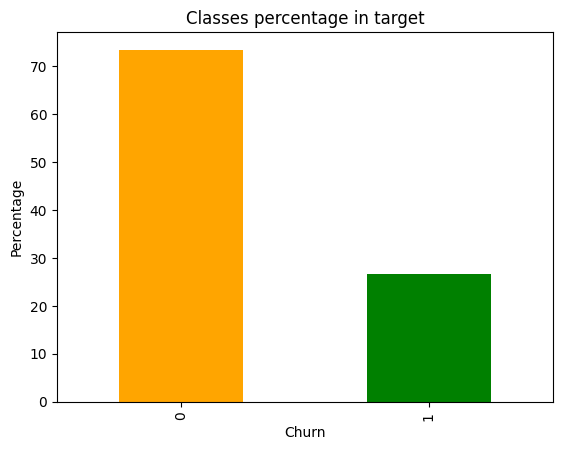

In [23]:
((y_train.value_counts(normalize=True)*100).round(2)).plot(kind='bar', color=['orange', 'green'])
plt.title("Classes percentage in target")
plt.ylabel("Percentage")

#### Comment:
It is clear that the data is imbalance. We should fix it.

### Under Sampling

In [24]:
## Resample 
rus = RandomUnderSampler(random_state=0)
X_train_resampled, y_train_resampled = rus.fit_resample(X_train, y_train)

print(X_train_resampled.shape, y_train_resampled.shape)

(2988, 23) (2988,)


In [25]:
## Model training and evaluation
rfc = RandomForestClassifier(n_estimators=100, random_state=42)
rfc.fit(X_train_resampled, y_train_resampled)

## Predict with model
y_train_pred = rfc.predict(X_train_resampled)
y_test_pred = rfc.predict(X_test)

## Evaluate
training_score = classification_report(y_train_resampled, y_train_pred)
test_score = classification_report(y_test, y_test_pred)

print("\n\nTraining Score\n", training_score, "\n\n\nTesting Score\n", test_score)



Training Score
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      1494
           1       1.00      1.00      1.00      1494

    accuracy                           1.00      2988
   macro avg       1.00      1.00      1.00      2988
weighted avg       1.00      1.00      1.00      2988
 


Testing Score
               precision    recall  f1-score   support

           0       0.90      0.76      0.82      1033
           1       0.53      0.76      0.62       372

    accuracy                           0.76      1405
   macro avg       0.71      0.76      0.72      1405
weighted avg       0.80      0.76      0.77      1405



In [26]:
## Model training and evaluation
rfc = RandomForestClassifier(max_depth=10, min_samples_leaf=15, n_estimators=200, random_state=42)
rfc.fit(X_train_resampled, y_train_resampled)

## Predict with model
y_train_pred = rfc.predict(X_train_resampled)
y_test_pred = rfc.predict(X_test)

## Evaluate
training_score = classification_report(y_train_resampled, y_train_pred)
test_score = classification_report(y_test, y_test_pred)

print("\n\nTraining Score\n", training_score, "\n\n\nTesting Score\n", test_score)



Training Score
               precision    recall  f1-score   support

           0       0.81      0.77      0.79      1494
           1       0.78      0.82      0.80      1494

    accuracy                           0.79      2988
   macro avg       0.79      0.79      0.79      2988
weighted avg       0.79      0.79      0.79      2988
 


Testing Score
               precision    recall  f1-score   support

           0       0.91      0.76      0.83      1033
           1       0.55      0.80      0.65       372

    accuracy                           0.77      1405
   macro avg       0.73      0.78      0.74      1405
weighted avg       0.82      0.77      0.78      1405



### Over Sampling

In [27]:
## Resample 
ros = RandomOverSampler(random_state=0)
X_train_resampled, y_train_resampled = ros.fit_resample(X_train, y_train)

print(X_train_resampled.shape, y_train_resampled.shape)

(8244, 23) (8244,)


In [28]:
## Model training and evaluation
rfc = RandomForestClassifier(max_depth=10, min_samples_leaf=15, n_estimators=200, random_state=42)
rfc.fit(X_train_resampled, y_train_resampled)

## Predict with model
y_train_pred = rfc.predict(X_train_resampled)
y_test_pred = rfc.predict(X_test)

## Evaluate
training_score = classification_report(y_train_resampled, y_train_pred)
test_score = classification_report(y_test, y_test_pred)

print("\n\nTraining Score\n", training_score, "\n\n\nTesting Score\n", test_score)



Training Score
               precision    recall  f1-score   support

           0       0.84      0.79      0.81      4122
           1       0.80      0.85      0.83      4122

    accuracy                           0.82      8244
   macro avg       0.82      0.82      0.82      8244
weighted avg       0.82      0.82      0.82      8244
 


Testing Score
               precision    recall  f1-score   support

           0       0.90      0.77      0.83      1033
           1       0.55      0.76      0.64       372

    accuracy                           0.77      1405
   macro avg       0.72      0.77      0.73      1405
weighted avg       0.81      0.77      0.78      1405



### SMOTE

In [29]:
## Resample 
smote = SMOTE(random_state=0)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print(X_train_resampled.shape, y_train_resampled.shape)

(8244, 23) (8244,)


In [30]:
## Model training and evaluation
rfc = RandomForestClassifier(max_depth=10, min_samples_leaf=15, n_estimators=200, random_state=42)
rfc.fit(X_train_resampled, y_train_resampled)

## Predict with model
y_train_pred = rfc.predict(X_train_resampled)
y_test_pred = rfc.predict(X_test)

## Evaluate
training_score = classification_report(y_train_resampled, y_train_pred)
test_score = classification_report(y_test, y_test_pred)

print("\n\nTraining Score\n", training_score, "\n\n\nTesting Score\n", test_score)



Training Score
               precision    recall  f1-score   support

           0       0.85      0.80      0.83      4122
           1       0.81      0.86      0.84      4122

    accuracy                           0.83      8244
   macro avg       0.83      0.83      0.83      8244
weighted avg       0.83      0.83      0.83      8244
 


Testing Score
               precision    recall  f1-score   support

           0       0.89      0.78      0.83      1033
           1       0.55      0.73      0.63       372

    accuracy                           0.77      1405
   macro avg       0.72      0.76      0.73      1405
weighted avg       0.80      0.77      0.78      1405



In [31]:
X_train.shape

(5616, 23)

In [32]:
param_grid = {
    'n_estimators': [200,300, 400],
    'max_depth': [8, 10,15],
    'min_samples_leaf': [15,18],
    'max_features': ['log2']
}

clf_grid = GridSearchCV(
    estimator = RandomForestClassifier(random_state=42),
    param_grid = param_grid,
    cv=5,
    n_jobs=-1
)

## Fit
clf_grid.fit(X_train_resampled, y_train_resampled)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [8, 10, ...], 'max_features': ['log2'], 'min_samples_leaf': [15, 18], 'n_estimators': [200, 300, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candid

In [33]:
## Get the best model
best_clf = clf_grid.best_estimator_

## Predict with model
y_train_pred = best_clf.predict(X_train_resampled)
y_test_pred = best_clf.predict(X_test)

## Evaluate
training_score = classification_report(y_train_resampled, y_train_pred)
test_score = classification_report(y_test, y_test_pred)

print("\n\nTraining Score\n", training_score, "\n\n\nTesting Score\n", test_score)



Training Score
               precision    recall  f1-score   support

           0       0.85      0.81      0.83      4122
           1       0.82      0.85      0.84      4122

    accuracy                           0.83      8244
   macro avg       0.83      0.83      0.83      8244
weighted avg       0.83      0.83      0.83      8244
 


Testing Score
               precision    recall  f1-score   support

           0       0.89      0.79      0.84      1033
           1       0.56      0.73      0.63       372

    accuracy                           0.78      1405
   macro avg       0.72      0.76      0.73      1405
weighted avg       0.80      0.78      0.78      1405



### Model Analysis
#### 1. Training vs. Testing Stability
* **The Overfitting Fix:** The previous model had a 1.00 training score (memorization). This new model shows 0.83 on training and 0.78 on testing. This is an excellent sign of a generalized model that will work on new, unseen data.

* **Consistency:** The precision and recall scores are balanced in training, which confirms that SMOTE successfully taught the model to treat both classes with equal importance.

#### 2. Class 1 (Churn) Performance
* **High Recall (0.73):** This is the most critical metric for your business. It is capturing 73% of all customers who will churn. This is a massive improvement over the initial 0.47 recall.

* **Precision Trade-off (0.56):** Because we used SMOTE to balance the data, the model is more "aggressive." About 44% of the "High Risk" predictions might actually be loyal customers. However, in Telco, the cost of a retention email is much lower than the cost of losing a customer.


#### 3. Metric Validity
* **F1-Score (0.63):** For an imbalanced dataset like IBM Telco, a Class 1 F1-score above 0.60 is considered a strong, deployment-ready baseline.

* **Weighted Avg (0.78):** This indicates that when considering the entire customer base, the model makes the correct decision 78% of the time.

### Export the model

In [35]:
import joblib

# Define the model metadata
model_metadata = {
    'model': best_clf,
    'features': X.columns.tolist(),
    'thresholds': {'Low': 0.3, 'High': 0.7}
}

# Export the model to a file
joblib.dump(model_metadata, '../Artifacts/Model/telco_churn_final_model.pkl')

print("Model exported successfully as 'telco_churn_final_model.pkl'")

Model exported successfully as 'telco_churn_final_model.pkl'


<br/>

---
### 👨‍💻 Author Information
**Name:** [Amaresh Maity]  
**Date:** 2026-02-23  
**Role:** [Data Scientist | AI Engineer]



#### Let's Connect!

If you have questions about this analysis or would like to collaborate, feel free to reach out:

* **LinkedIn:** [LinkedIn](https://www.linkedin.com/in/amareshmaity/)
* **GitHub:** [@amareshmaity](https://github.com/amareshmaity)
* **Email:** [contacttoamaresh@gmail.com](mailto:contacttoamaresh@gmail.com)